In [1]:
import pandas as pd

# Load data
df = pd.read_csv("car data.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData types:")
print(df.dtypes)

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Shape: (301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         obj

In [3]:
# Check data
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape after cleaning:", df.shape)

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2

Shape after cleaning: (299, 9)


In [5]:
# Summary
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


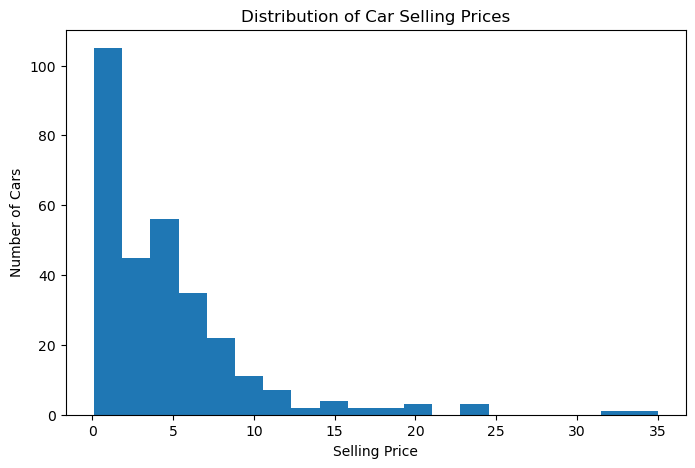

In [7]:
import matplotlib.pyplot as plt

# Price distribution
plt.figure(figsize=(8, 5))

plt.hist(df["Selling_Price"], bins=20)

plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Selling Prices")

plt.show()

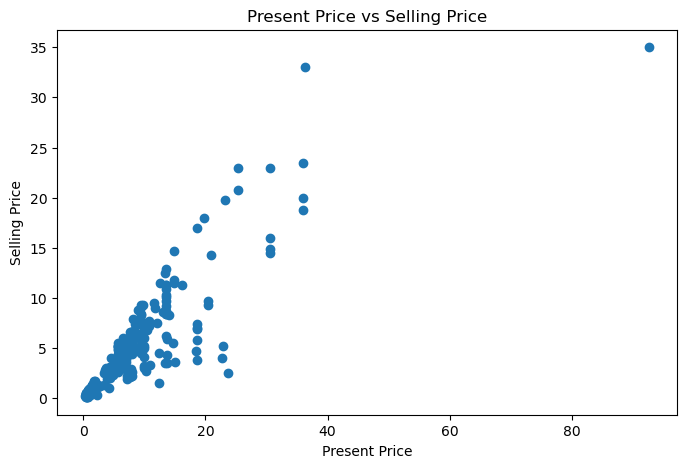

In [8]:
# Price relationship
plt.figure(figsize=(8, 5))

plt.scatter(df["Present_Price"], df["Selling_Price"])

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")

plt.show()

In [10]:
# Create car age
df["Car_Age"] = 2026 - df["Year"]

print(df[["Year", "Car_Age", "Selling_Price"]].head())

   Year  Car_Age  Selling_Price
0  2014       12           3.35
1  2013       13           4.75
2  2017        9           7.25
3  2011       15           2.85
4  2014       12           4.60


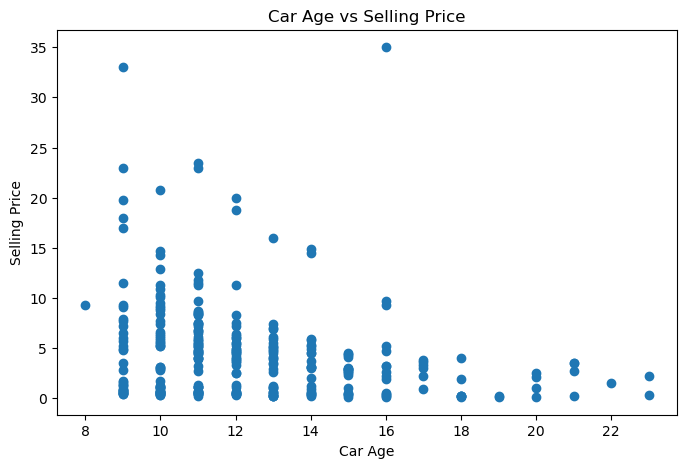

In [13]:
# Age vs price
plt.figure(figsize=(8, 5))

plt.scatter(df["Car_Age"], df["Selling_Price"])

plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")

plt.show()

In [15]:
# Encode categories
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df = df.drop(["Car_Name", "Year"], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [17]:
from sklearn.model_selection import train_test_split

# Prepare data
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest")
print("-------------")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

Random Forest
-------------
MAE : 1.47
MSE : 12.32
RMSE: 3.51
R²  : 0.52


In [23]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("-----------------")
print("MAE :", round(gb_mae, 2))
print("MSE :", round(gb_mse, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 2))

Gradient Boosting
-----------------
MAE : 1.21
MSE : 8.04
RMSE: 2.84
R²  : 0.69


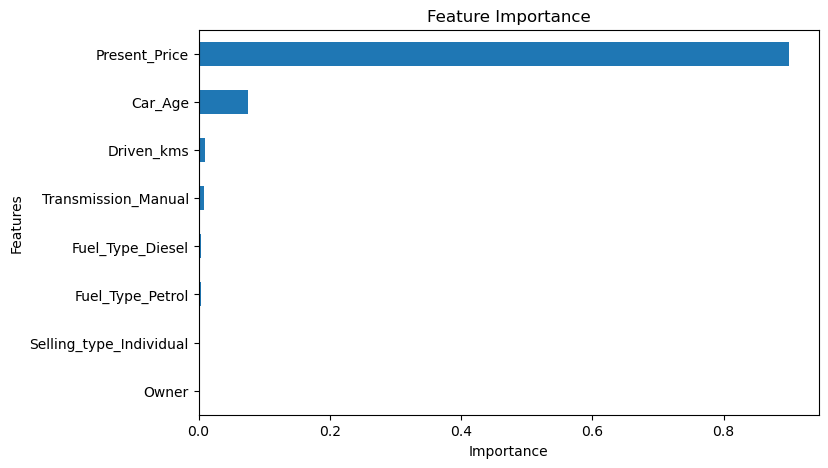

In [25]:
# Feature importance
importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

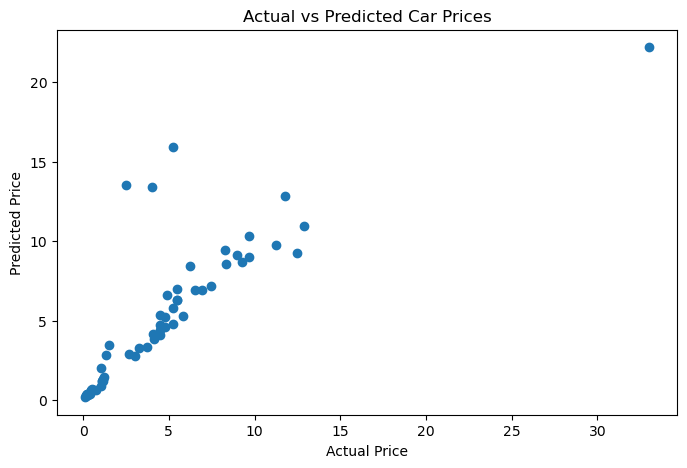

In [27]:
# Actual vs predicted
plt.figure(figsize=(8, 5))

plt.scatter(y_test, gb_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [29]:
# Prediction results
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": gb_pred
})

result.head(10)

,Actual Price,Predicted Price
0,8.99,9.104991
1,8.35,8.542175
2,0.45,0.582642
3,7.45,7.165051
4,5.25,15.924239
5,5.25,4.827438
6,5.85,5.283347
7,1.15,1.320304
8,9.25,8.689363
9,0.38,0.385777


In [31]:
# New car prediction
car = pd.DataFrame([{
    "Present_Price": 5.59,
    "Driven_kms": 27000,
    "Owner": 0,
    "Car_Age": 5,
    "Fuel_Type_Diesel": 0,
    "Fuel_Type_Petrol": 1,
    "Selling_type_Individual": 0,
    "Transmission_Manual": 1
}])

prediction = gb_model.predict(car)

print("Predicted Selling Price:", round(prediction[0], 2), "lakhs")

Predicted Selling Price: 3.93 lakhs


In [33]:
# Manual prediction

import pandas as pd

print("\nEnter car details")
print("Valid ranges:")
print("Present Price: 0.32 - 92.60 lakhs")
print("Driven Kms: 500 - 500000 km")
print("Owners: 0 - 3")
print("Car Age: 2 - 21 years")
print("Fuel: Petrol / Diesel")
print("Selling Type: Dealer / Individual")
print("Transmission: Manual / Automatic\n")


present_price = float(input("Enter present price: "))

if not 0.32 <= present_price <= 92.60:
    print("Error: Present price must be between 0.32 and 92.60 lakhs.")
else:
    driven_kms = int(input("Enter kilometers driven: "))

    if not 500 <= driven_kms <= 500000:
        print("Error: Driven kilometers must be between 500 and 500000.")
    else:
        owner = int(input("Enter number of previous owners: "))

        if not 0 <= owner <= 3:
            print("Error: Number of owners must be between 0 and 3.")
        else:
            car_age = int(input("Enter car age: "))

            if not 2 <= car_age <= 21:
                print("Error: Car age must be between 2 and 21 years.")
            else:
                fuel = input("Enter fuel type (Petrol/Diesel): ").strip().lower()

                if fuel not in ["petrol", "diesel"]:
                    print("Error: Enter Petrol or Diesel.")
                else:
                    selling_type = input(
                        "Enter selling type (Dealer/Individual): "
                    ).strip().lower()

                    if selling_type not in ["dealer", "individual"]:
                        print("Error: Enter Dealer or Individual.")
                    else:
                        transmission = input(
                            "Enter transmission (Manual/Automatic): "
                        ).strip().lower()

                        if transmission not in ["manual", "automatic"]:
                            print("Error: Enter Manual or Automatic.")
                        else:

                            if fuel == "diesel":
                                fuel_diesel = 1
                                fuel_petrol = 0
                            else:
                                fuel_diesel = 0
                                fuel_petrol = 1

                            if selling_type == "individual":
                                selling_individual = 1
                            else:
                                selling_individual = 0

                            if transmission == "manual":
                                transmission_manual = 1
                            else:
                                transmission_manual = 0

                            car = pd.DataFrame([{
                                "Present_Price": present_price,
                                "Driven_kms": driven_kms,
                                "Owner": owner,
                                "Car_Age": car_age,
                                "Fuel_Type_Diesel": fuel_diesel,
                                "Fuel_Type_Petrol": fuel_petrol,
                                "Selling_type_Individual": selling_individual,
                                "Transmission_Manual": transmission_manual
                            }])

                            prediction = gb_model.predict(car)

                            print("\n-----------------------------")
                            print(
                                "Predicted Selling Price:",
                                round(prediction[0], 2),
                                "lakhs"
                            )
                            print("-----------------------------")


Enter car details
Valid ranges:
Present Price: 0.32 - 92.60 lakhs
Driven Kms: 500 - 500000 km
Owners: 0 - 3
Car Age: 2 - 21 years
Fuel: Petrol / Diesel
Selling Type: Dealer / Individual
Transmission: Manual / Automatic



Enter present price:  55.9
Enter kilometers driven:  5000
Enter number of previous owners:  2
Enter car age:  6
Enter fuel type (Petrol/Diesel):  petrol
Enter selling type (Dealer/Individual):  dealer
Enter transmission (Manual/Automatic):  manual



-----------------------------
Predicted Selling Price: 21.05 lakhs
-----------------------------
